**Recompile et loads all classes**

In [37]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Importation of our class from other files 

In [38]:
from Main_functions import Potential_extraction
from Main_functions import Generation_quad
from Main_functions import Data_exploitation
from Main_functions import ParaxialSimulation
from Main_functions import Data_exploitation_whitoutfit
from Extraction_data import Extracted_data
from Okayama_quad import Okayama_quad
from Multipolar_decomposition import Decomposition
from Fit_functions import Fit_constants
from Paraxial import Ion
import numpy as np

**Initialisation of tensions**

In [39]:
Va = 20000
tension = {
    "va1":  0.18808 * Va,   # Tension Aperture 1
    "va2": -0.18808 * Va,    # Tension Aperture 2
    "vq13": 0.0299087 * Va,    # Tension Quad 1&3
    "vq24": -0.0299087 * Va,      #Tension quad 2 et 4        
    "vaAc": Va,               # Tension acceleation
}
out_dir = "files"

**Creation of a .npz file to reconstruct one quadrupole from unitary potentials**

In [40]:
quad = Generation_quad(tension, out_dir)
file_path_quad = quad.reconstruction()

Reconstructed file saved : files\quad_reconstuit.npz


**Path to the files**

In [41]:
#files with our potential data
file_pathl = r"Programs\Files\potentiel_quadrupole_VF.npz"

**Exploitation of data from the files**

In [42]:
extracted_data = Extracted_data(file_path_quad) 
extracted_data.derivative()
fit_constants = Fit_constants(0.80751, 5.08, 2.54, 0.03891461, 3.113, 2.015, 2.4, 3.493e-3, extracted_data)
fun = Data_exploitation(extracted_data, fit_constants)
print(extracted_data.coord_apert_z1)
Decomp= Decomposition(extracted_data)
Decomp.components()

6


**Plot of the multipolar decomposition of the potential along the z axis**

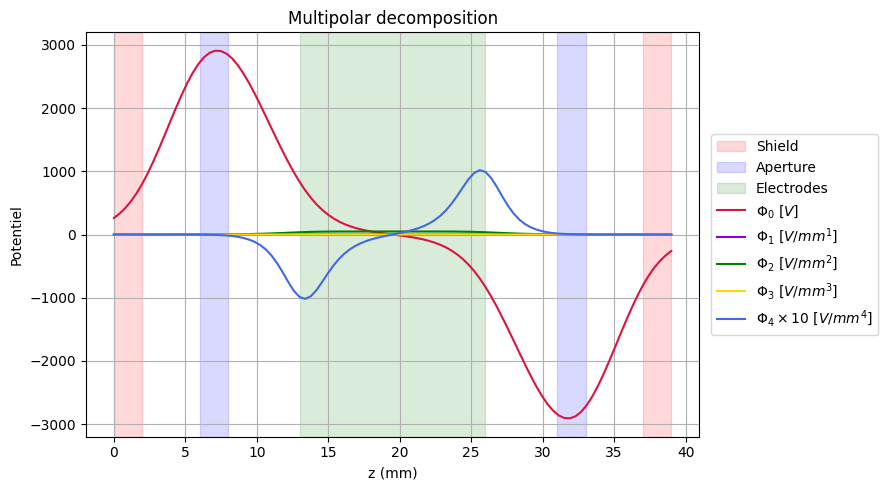

In [43]:
fun.decomposition_calculation()
fun.decomposition_graph()

**Normalized plot of the multipolar decomposition of the potential along the z axis**

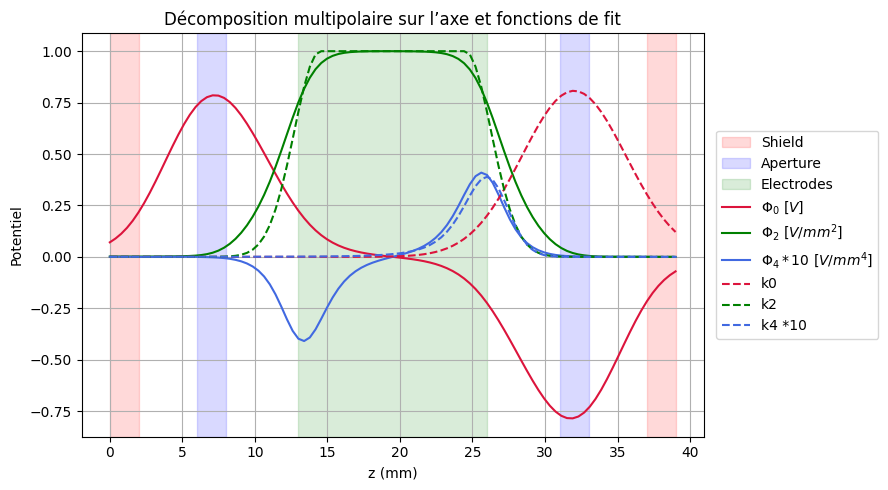

In [44]:
fun.fit_calculation()
fun.fit_graph()

**Paraxial trajectories for 2 ions**

20000
20000


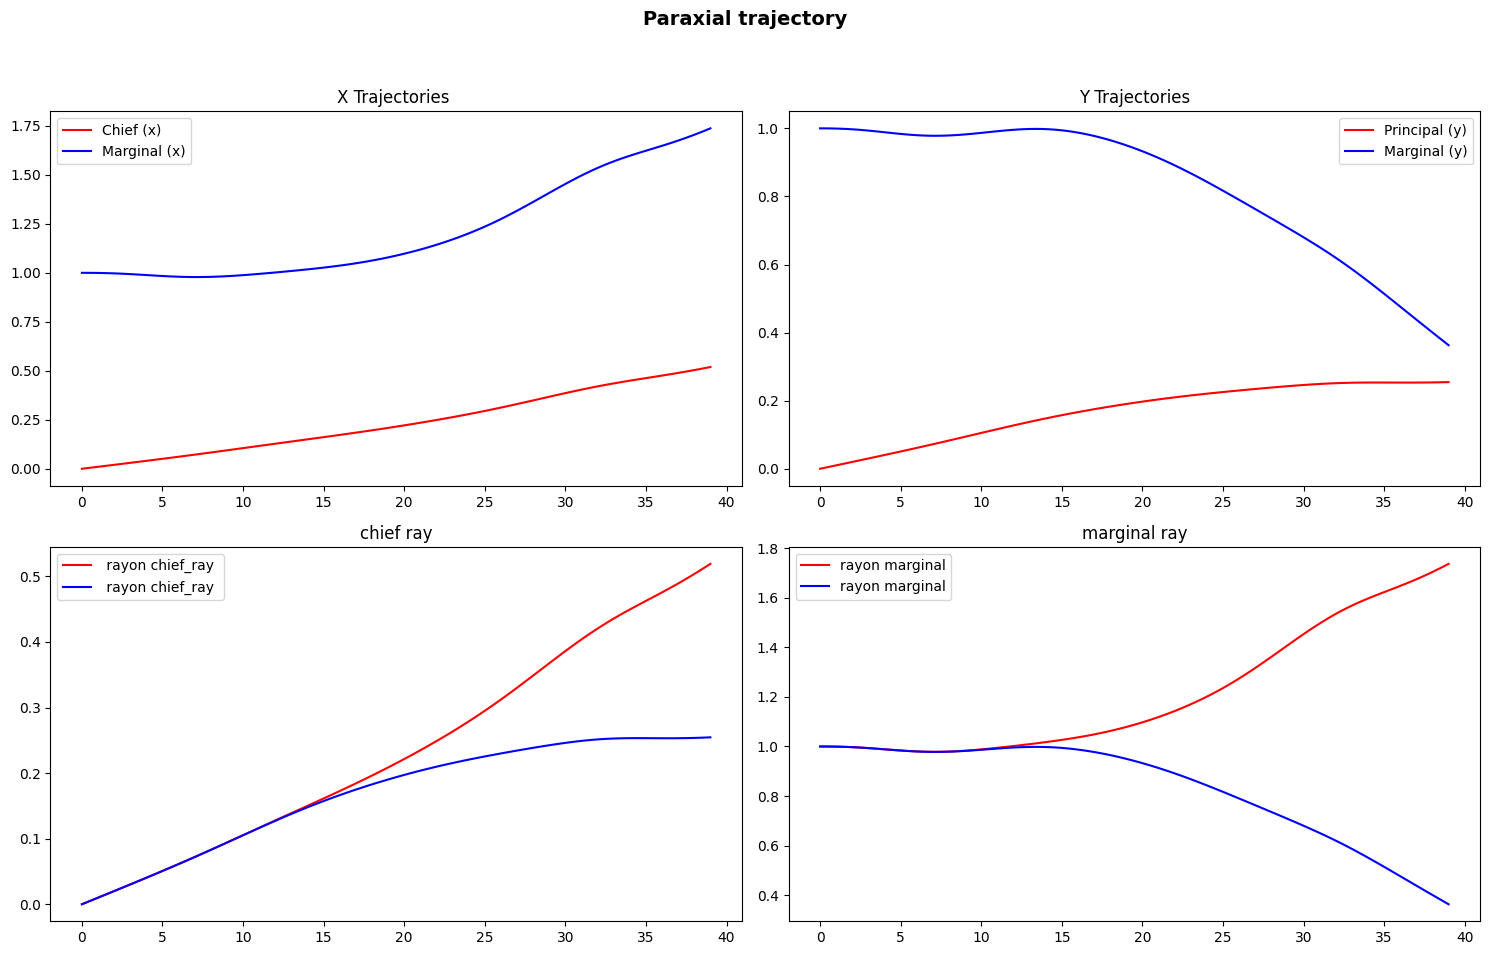

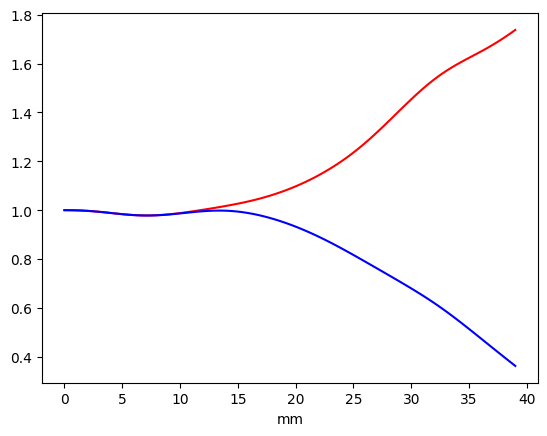

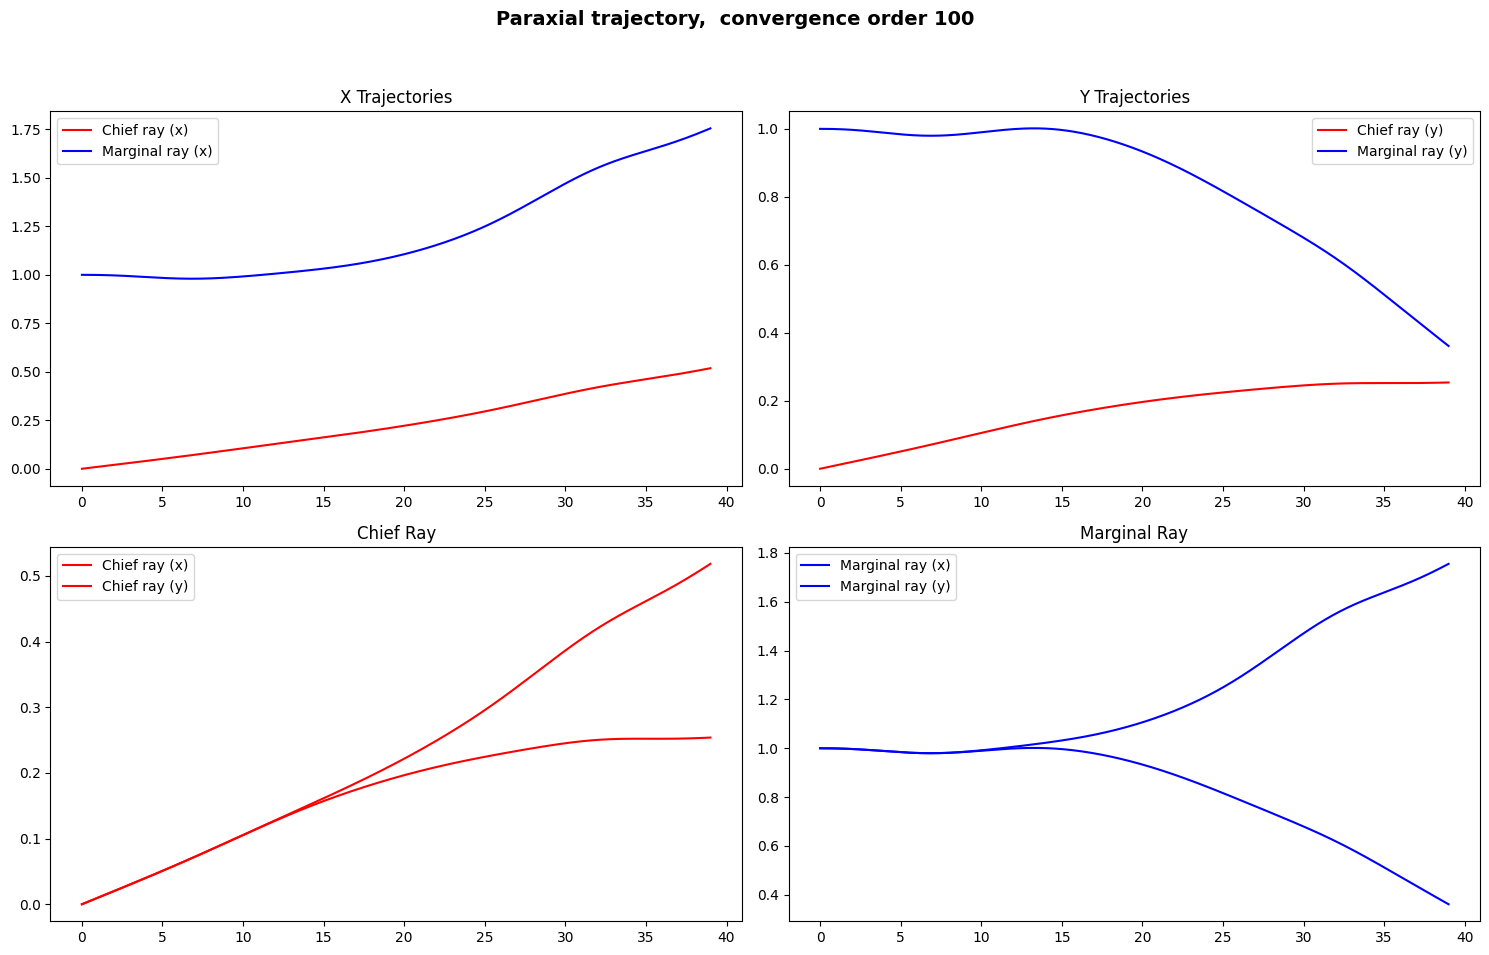

In [45]:
n = 100 #order of convergence
e = -1.6e-19 #electron charge

marginal = Ion(1.6e-27, e, "chief", 0, 0.01, 0, 0.01)
chief = Ion(1.6e-27, e, "marginal", 1, 0, 1, 0)

marginal_continuus = Ion(1.6e-27, e, "marginal", 0, 0.01, 0, 0.01)
chief_continuus = Ion(1.6e-27, e, "chief", 1, 0, 1, 0)

Trajectory = ParaxialSimulation(extracted_data, Decomp)
Trajectory.run_discrete(marginal, chief)

Trajectory.run_convergence(marginal_continuus, chief_continuus, n)

**Paraxial trajectories of n ions**

20000
20000
20000
20000
20000


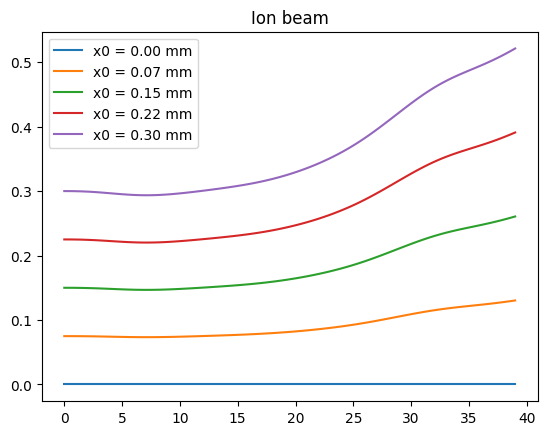

In [46]:
list = [] #beam

nb = 5 #number of ions

initial_position = np.linspace(0, 0.3, nb)
for i in initial_position:
    ion= Ion(1.6e-27, e, f"Ion_{i:.1f}", i, 0.00, i, 0.00)
    list.append(ion)

Trajectory.run_beam(list)

**Okayama's system**

In [47]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [48]:
#Entire quadrupoles
Va = 200000 #20 kv

tension_quad1 = {
    "va1":  0, #Tension Aperture 1
    "va2": 0, #Tension Aperture 2
    "vq13": 0.030872 * Va, #Tension Quad 1&3
    "vq24": -0.030872* Va, #Tension quad 2 et 4        
    "vaAc": Va, #Tension acceleation
}

tension_quad2= {
    "va1":  -0.188084 * Va, #Tension Aperture 1
    "va2": 0.109177 * Va, #Tension Aperture 2
    "vq13": -0.029909 * Va, #Tension Quad 1&3
    "vq24": 0.029909 * Va, #Tension quad 2 et 4        
    "vaAc": Va, #Tension acceleation
}

tension_quad3= {
    "va1":  0.109177 * Va, #Tension Aperture 1
    "va2": -0.188084 * Va, #Tension Aperture 2
    "vq13": 0.029909 * Va, #Tension Quad 1&3
    "vq24": -0.029909 * Va, #Tension quad 2 et 4        
    "vaAc": Va, #Tension acceleation
}

tension_quad4= {
    "va1":  0, #Tension Aperture 1
    "va2": 0, #Tension Aperture 2
    "vq13": -0.030872 * Va, #Tension Quad 1&3
    "vq24": 0.030872 * Va, #Tension quad 2 et 4        
    "vaAc": Va, #Tension acceleation
}

tension_list =[tension_quad1, tension_quad2, tension_quad3, tension_quad4]
z_list = [0, 37, 92.5, 128.5]
out_dir = "files"

In [49]:
okayama = Okayama_quad(out_dir, z_list, tension_list)
Okayama_path = okayama.save("okayama_quad.npz")

 File saved for Extracted_data : files\okayama_quad.npz


In [50]:
extracted_data2 = Extracted_data(Okayama_path, z_list) 
extracted_data2.derivative()
extracted_data2.position_quad()
Decomp2= Decomposition(extracted_data2)
quad_ent = Data_exploitation_whitoutfit(extracted_data2)
Decomp2.components()

[0, 37, 92.5, 128.5]


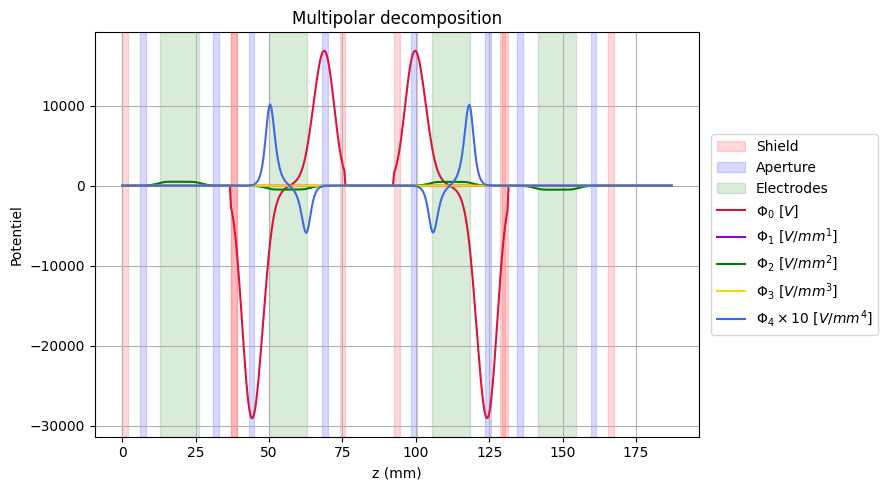

In [51]:
quad_ent.decomposition_calculation()
quad_ent.decomposition_graph()

[0, 37, 92.5, 128.5]


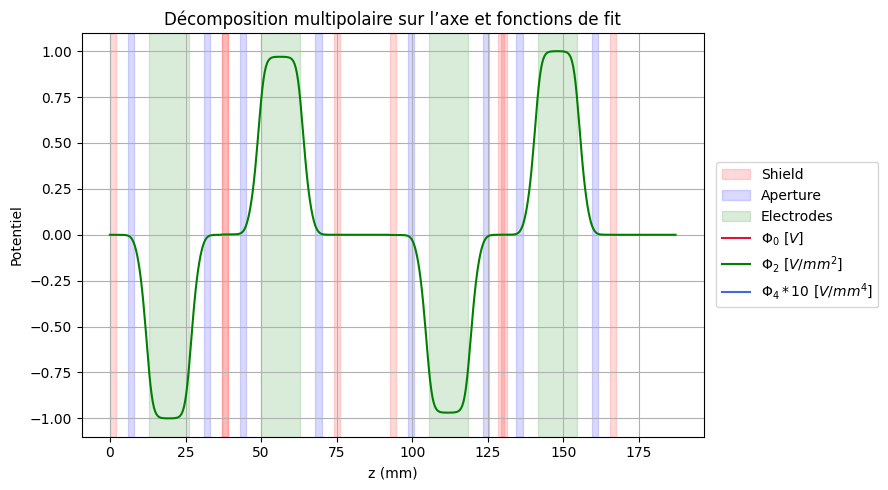

In [52]:
quad_ent.fit_graph()

200000
200000


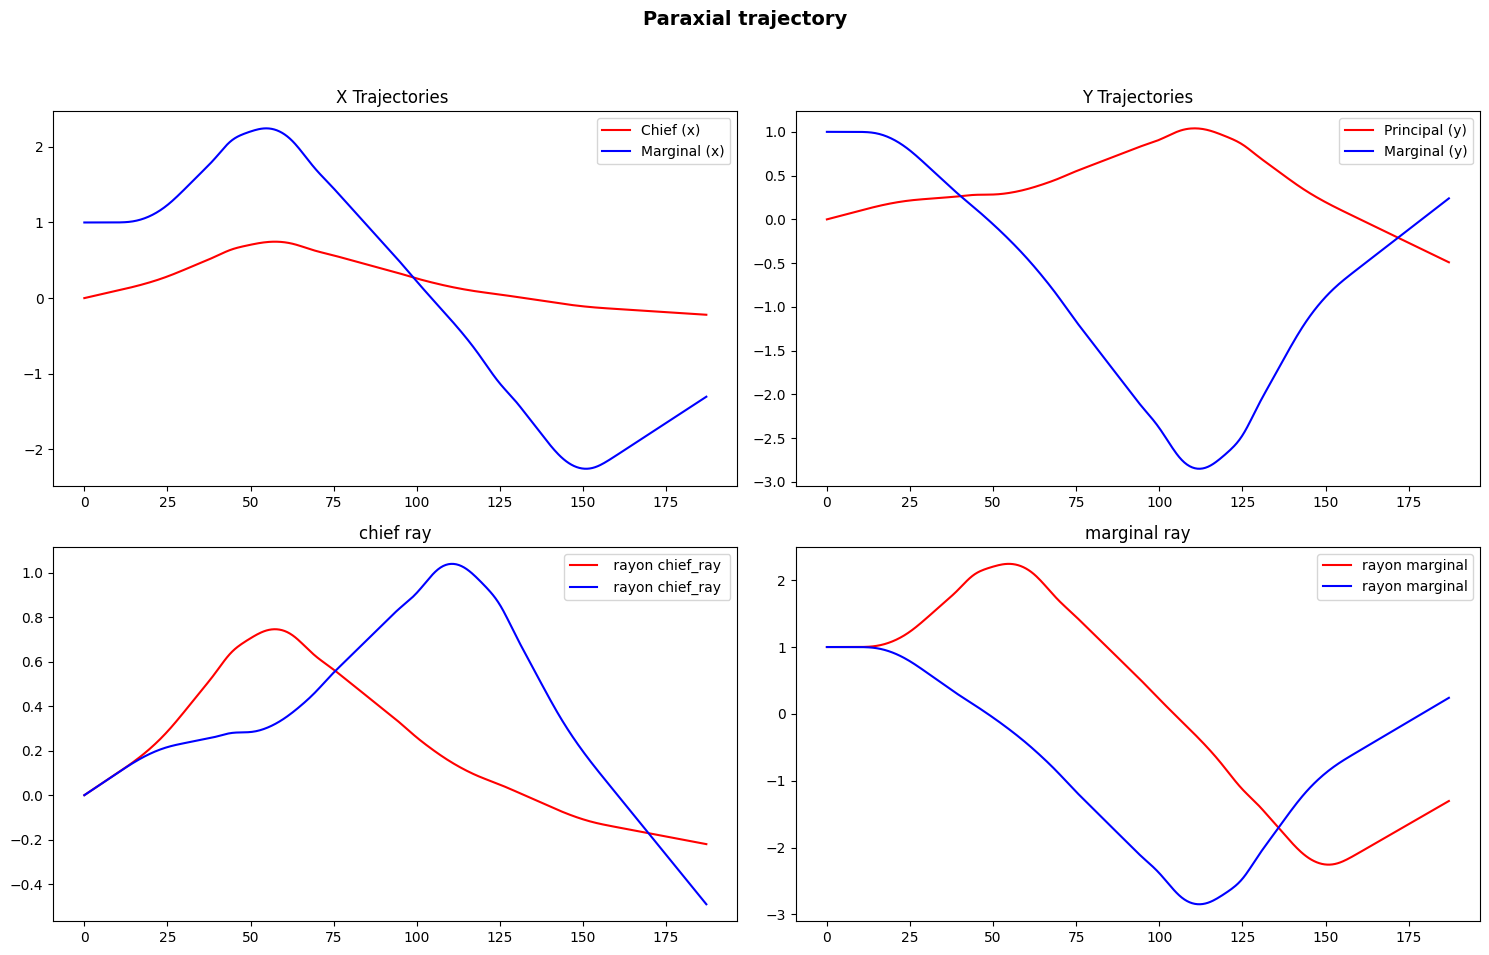

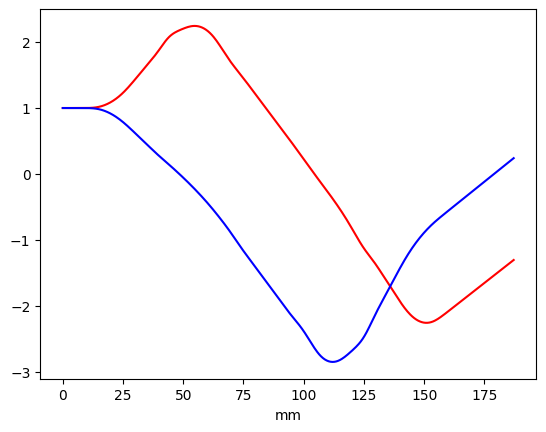

In [53]:
n = 100
e = -1.6e-19

marginal = Ion(1.6e-27, e, "chief", 0, 0.01, 0, 0.01)
chief = Ion(1.6e-27, e, "marginal", 1, 0, 1, 0)

marginal_continuus = Ion(1.6e-27, e, "marginal", 0, 0.01, 0, 0.01)
chief_continuus = Ion(1.6e-27, e, "chief", 1, 0, 1, 0)

trajectory = ParaxialSimulation(extracted_data2, Decomp2)
trajectory.run_discrete(marginal, chief)

In [54]:
#partie analytique 
trajectory.plot_analytical_solution(extracted_data, Decomp)

TypeError: ParaxialSimulation.plot_analytical_solution() takes 2 positional arguments but 3 were given